<a href="https://www.kaggle.com/code/taraskin5201/practical-nn-my?scriptVersionId=294618203" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [162]:
import torch  
from torchvision import datasets, transforms 

In [163]:
data_dir = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_0"

In [164]:
dataset0 = datasets.ImageFolder(data_dir)

In [165]:
len(dataset0)

3527

In [166]:
img, label = dataset0[3526]

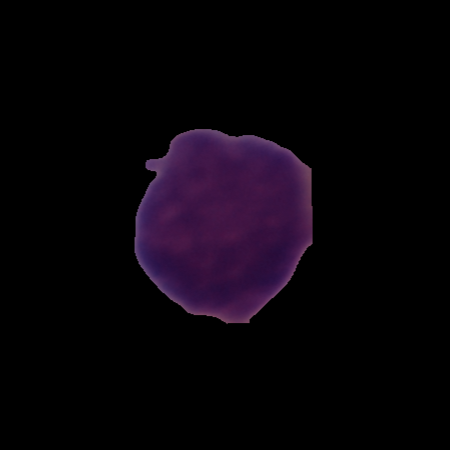

In [167]:
img

In [168]:
dataset0.classes

['all', 'hem']

In [169]:
data_dir1 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_1"
dataset1 = datasets.ImageFolder(data_dir1)

data_dir2 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_2"
dataset2 = datasets.ImageFolder(data_dir2)

In [170]:
dataset0.classes
dataset1.classes
dataset2.classes

['all', 'hem']

In [171]:
dataset_all = torch.utils.data.ConcatDataset([dataset0, dataset1, dataset2])

In [172]:
len(dataset_all)

10661

In [173]:
data_train, data_test = torch.utils.data.random_split(dataset_all,[0.8, 0.2])

In [174]:
len(data_train)


8529

In [175]:
len(data_test)


2132

In [176]:
img, label = data_train[5000]

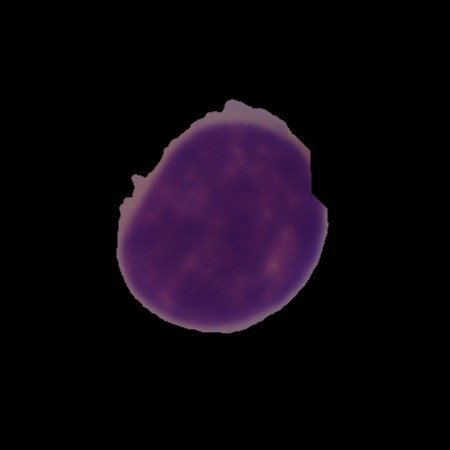

In [177]:
img

In [178]:
train_transform = transforms.Compose(
    [transforms.Resize([200, 200]),
    transforms.CenterCrop(180),
    transforms.RandomRotation(180),
    transforms.ToTensor()
    ]
)

In [179]:
train_transform(img).shape

torch.Size([3, 180, 180])

In [180]:
test_transform = transforms.Compose(
    [transforms.Resize([200, 200]),
    transforms.CenterCrop(180),
    transforms.ToTensor()
    ]
)

In [181]:
test_transform(img).shape

torch.Size([3, 180, 180])

In [182]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]

        new_img = self.transformer(img)
        
        return new_img, y

In [183]:
train_data = TransformDataset(data_train,train_transform)

In [184]:
test_data = TransformDataset(data_test,test_transform)

In [185]:
len(test_data)

2132

In [186]:
test_data[2100]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 0)

In [187]:
train_loader = DataLoader(train_data, batch_size=256)

In [188]:
test_loader = DataLoader(test_data, batch_size=256)


In [189]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 


torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([84, 3, 180, 180])
torch.Size([84])


(180, 180, 3)


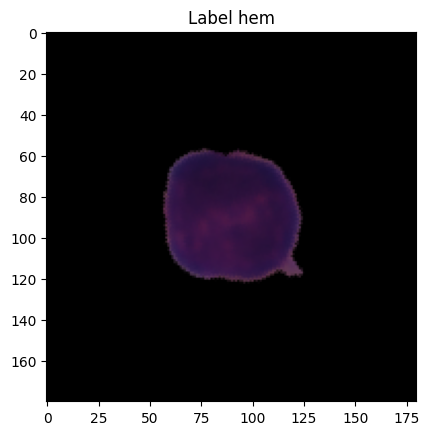

(180, 180, 3)


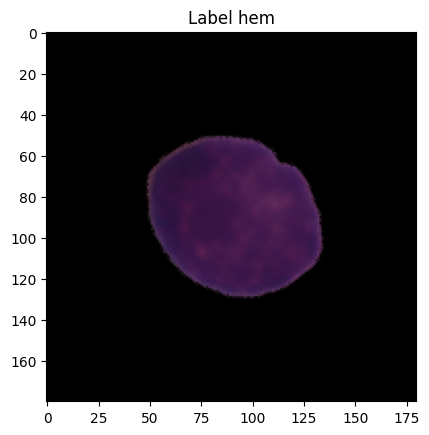

(180, 180, 3)


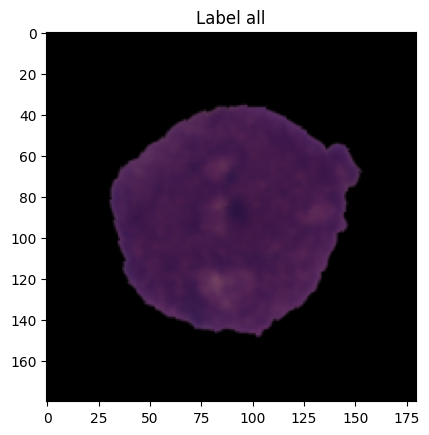

In [190]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset0.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

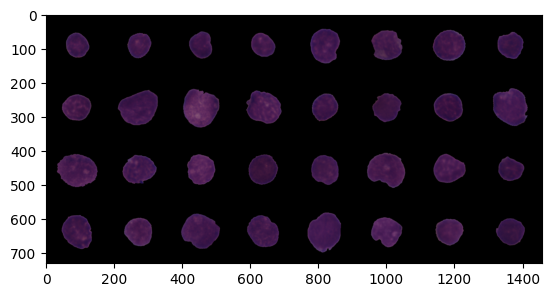

In [191]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

  
batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [192]:
3*60*60

10800

In [193]:
# from torch import nn

# model = nn.Sequential(
#     nn.Flatten(),
#     nn.Linear(10800, 64),
#     nn.ReLU(),
#     nn.Linear(64, 32),
#     nn.ReLU(),
#     nn.Linear(32, 16),
#     nn.ReLU(),
#     nn.Linear(16, 2)
# )

# device = "cuda"
# model = model.to(device)

from torch import nn

model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding='same'),# розмір буде 8,180,180
    nn.ReLU(),
    nn.MaxPool2d(2,2), #8, 90 , 90
    nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding='same'),#16, 90, 90
    nn.ReLU(), # 16, 90, 90
    nn.MaxPool2d(2, 2), # 16, 45, 45
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding='same'), #32, 45, 45
    nn.ReLU(), #32, 45, 45
    nn.MaxPool2d(2, 2), # 32, 22, 22

    nn.Flatten(), # 32*22*22 - 15488
    nn.Linear(15488, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)

device = 'cuda'
model = model.to(device)

In [194]:
32*22*22

15488

In [195]:
for imgs, labels in train_loader:
    break

In [196]:
imgs.shape

torch.Size([256, 3, 180, 180])

In [197]:
# функция ошибки для задачи многоклассовой классификации
loss_fn = nn.CrossEntropyLoss()

# оптимизатор Adam для обучения нейронной сети
optimizer = torch.optim.Adam(
    model.parameters(),   # параметры модели
    lr=0.001
)

# список для сохранения значений loss во время обучения
loss_list = []
loss_test_list = []

# цикл обучения по эпохам
for i in range(3):

    # перебор батчей из обучающего даталоадера
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        loss.backward()               # вычисление градиентов
        optimizer.step()              # обновление весов модели
        optimizer.zero_grad()         # очистка градиентов

        loss_list.append(loss.cpu().item())  # сохранение значения loss

    #test data
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        

        loss_test_list.append(loss.cpu().item())  # сохранение значения loss


loss: 0.6752583980560303
loss: 0.6450473070144653
loss: 0.6205316185951233
loss: 0.6258353590965271
loss: 0.6045642495155334
loss: 0.6504550576210022
loss: 0.6814337968826294
loss: 0.585761547088623
loss: 0.6232359409332275
loss: 0.6490445137023926
loss: 0.6188976764678955
loss: 0.6156732439994812
loss: 0.618922233581543
loss: 0.620784342288971
loss: 0.5826283693313599
loss: 0.580902099609375
loss: 0.6101003885269165
loss: 0.61892169713974
loss: 0.5826142430305481
loss: 0.5803425908088684
loss: 0.5448442697525024
loss: 0.5144568681716919
loss: 0.5289197564125061
loss: 0.5189766883850098
loss: 0.520534336566925
loss: 0.4704820513725281
loss: 0.4927545189857483
loss: 0.4888173043727875
loss: 0.4644562005996704
loss: 0.4879639744758606
loss: 0.4402126371860504
loss: 0.4151778817176819
loss: 0.4942055940628052
loss: 0.4810851812362671
loss: 0.5127207636833191
loss: 0.548035204410553
loss: 0.4952238202095032
loss: 0.46523362398147583
loss: 0.48789507150650024
loss: 0.4485202729701996
loss: 

In [198]:
imgs.shape

torch.Size([81, 3, 180, 180])

In [199]:
# image = torch.rand(1, 3, 180, 180)
# image

tensor([[[[0.2086, 0.6252, 0.5245,  ..., 0.3431, 0.2688, 0.6786],
          [0.1235, 0.0114, 0.7316,  ..., 0.0887, 0.5772, 0.7566],
          [0.7771, 0.7635, 0.4864,  ..., 0.7124, 0.1218, 0.9453],
          ...,
          [0.8247, 0.3879, 0.9604,  ..., 0.7038, 0.6808, 0.9978],
          [0.8584, 0.9447, 0.9063,  ..., 0.7148, 0.0782, 0.9385],
          [0.2363, 0.7674, 0.4969,  ..., 0.9029, 0.4529, 0.1287]],

         [[0.5977, 0.8073, 0.3215,  ..., 0.0193, 0.4787, 0.7560],
          [0.2108, 0.9346, 0.3849,  ..., 0.3222, 0.3337, 0.4408],
          [0.1822, 0.6291, 0.6839,  ..., 0.4050, 0.1262, 0.1770],
          ...,
          [0.4614, 0.7776, 0.0142,  ..., 0.0586, 0.7595, 0.8417],
          [0.7282, 0.4799, 0.3700,  ..., 0.8127, 0.8141, 0.2934],
          [0.1587, 0.6147, 0.1983,  ..., 0.2781, 0.1629, 0.1115]],

         [[0.4880, 0.5081, 0.8225,  ..., 0.9925, 0.6301, 0.2509],
          [0.0519, 0.7402, 0.8929,  ..., 0.2497, 0.9416, 0.1285],
          [0.0988, 0.4041, 0.4380,  ..., 0

In [200]:
# torch.onnx.export(
#     model.to('cpu'),
#     image,
#     'leukemia.onnx',
#     input_names = ['input'],
#     output_names = ['output']
# )

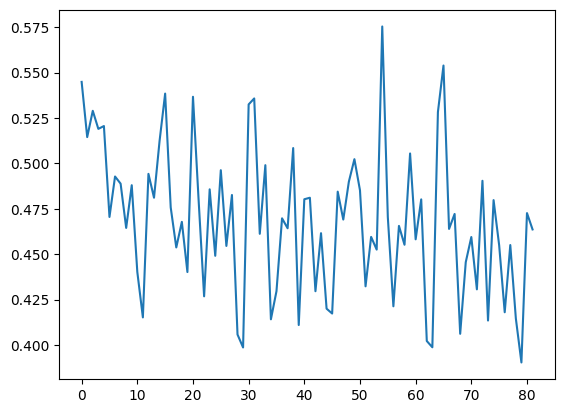

In [201]:
import matplotlib.pyplot as plt

new_list = loss_list[20 :]

plt.plot(new_list)



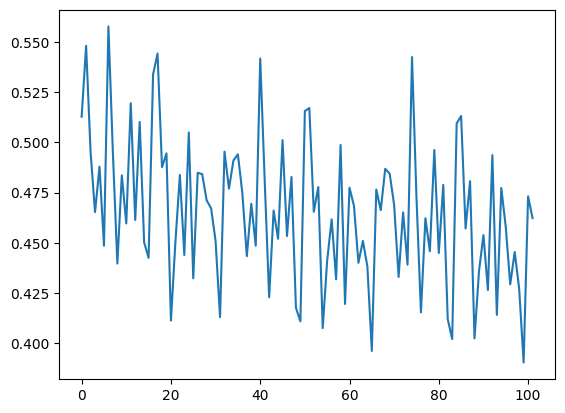

In [202]:
plt.plot(loss_test_list)

In [203]:
imgs.shape

torch.Size([81, 3, 180, 180])

In [204]:
img, label = train_data[100]
img = img.unsqueeze(0)
img.shape

torch.Size([1, 3, 180, 180])

In [205]:
img = img.to("cpu")
prediction = model(img)
print(label)
print(nn.Softmax()(prediction))

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [ ]:
result = model(imgs)

In [ ]:
res1 = result.argmax(dim=1)

In [ ]:
labels

In [ ]:
res2 = res1 == labels

In [ ]:
res2.sum()

In [ ]:
67/81

In [ ]:
count = 0



for imgs, labels in train_loader:
    imgs = imgs.to(device)
    labels = labels.to(device)
    res = model(imgs)
    res = res.argmax(dim=1)
    res2 = res == labels
    summa = res2.sum()
    count += summa.cpu().item()

print(count) 

In [ ]:
len(train_data) 

In [ ]:
6829/8529